# **4. Recolección de los Datos**

In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

##Importación de los datos
data = pd.read_csv('datos_caso_6.csv')
data

,loan_status,annual_inc,verification_status,emp_length,home_ownership,int_rate,loan_amnt,purpose,term,grade
0,Fully Paid,24000.0,Verified,10+ years,RENT,10.65%,5000,credit_card,36 months,B
1,Charged Off,30000.0,Source Verified,< 1 year,RENT,15.27%,2500,car,60 months,C
2,Fully Paid,12252.0,Not Verified,10+ years,RENT,15.96%,2400,small_business,36 months,C
3,Fully Paid,49200.0,Source Verified,10+ years,RENT,13.49%,10000,other,36 months,C
4,Fully Paid,80000.0,Source Verified,1 year,RENT,12.69%,3000,other,60 months,B
...,...,...,...,...,...,...,...,...,...,...
38700,Fully Paid,110000.0,Not Verified,4 years,MORTGAGE,8.07%,2500,home_improvement,36 months,A
38701,Fully Paid,18000.0,Not Verified,3 years,RENT,10.28%,8500,credit_card,36 months,C
38702,Fully Paid,100000.0,Not Verified,< 1 year,MORTGAGE,8.07%,5000,debt_consolidation,36 months,A
38703,Fully Paid,200000.0,Not Verified,< 1 year,MORTGAGE,7.43%,5000,other,36 months,A


# **5. Entendimiento de los datos**

- Datos nulos
- Estadísticas univariada, bivariada y multivariada
- Desbalance de y

In [3]:
import matplotlib.pyplot as plt
import seaborn as sb

In [4]:
#Identificación de datos nulos
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38705 entries, 0 to 38704
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   loan_status          38705 non-null  object 
 1   annual_inc           38705 non-null  float64
 2   verification_status  38705 non-null  object 
 3   emp_length           38705 non-null  object 
 4   home_ownership       38705 non-null  object 
 5   int_rate             38705 non-null  object 
 6   loan_amnt            38705 non-null  int64  
 7   purpose              38705 non-null  object 
 8   term                 38705 non-null  object 
 9   grade                38705 non-null  object 
dtypes: float64(1), int64(1), object(8)
memory usage: 3.0+ MB


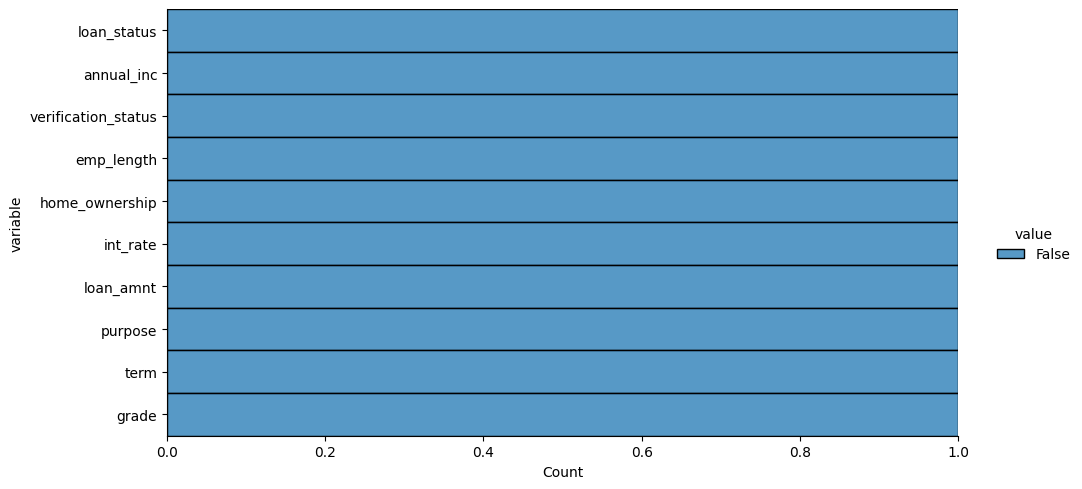

In [5]:
#Visualizar la proporción de datos nulos por variable
data.isnull().melt().pipe(lambda df: sb.displot(data = df, y = 'variable', hue = 'value', multiple = 'fill', aspect = 2))
plt.show()

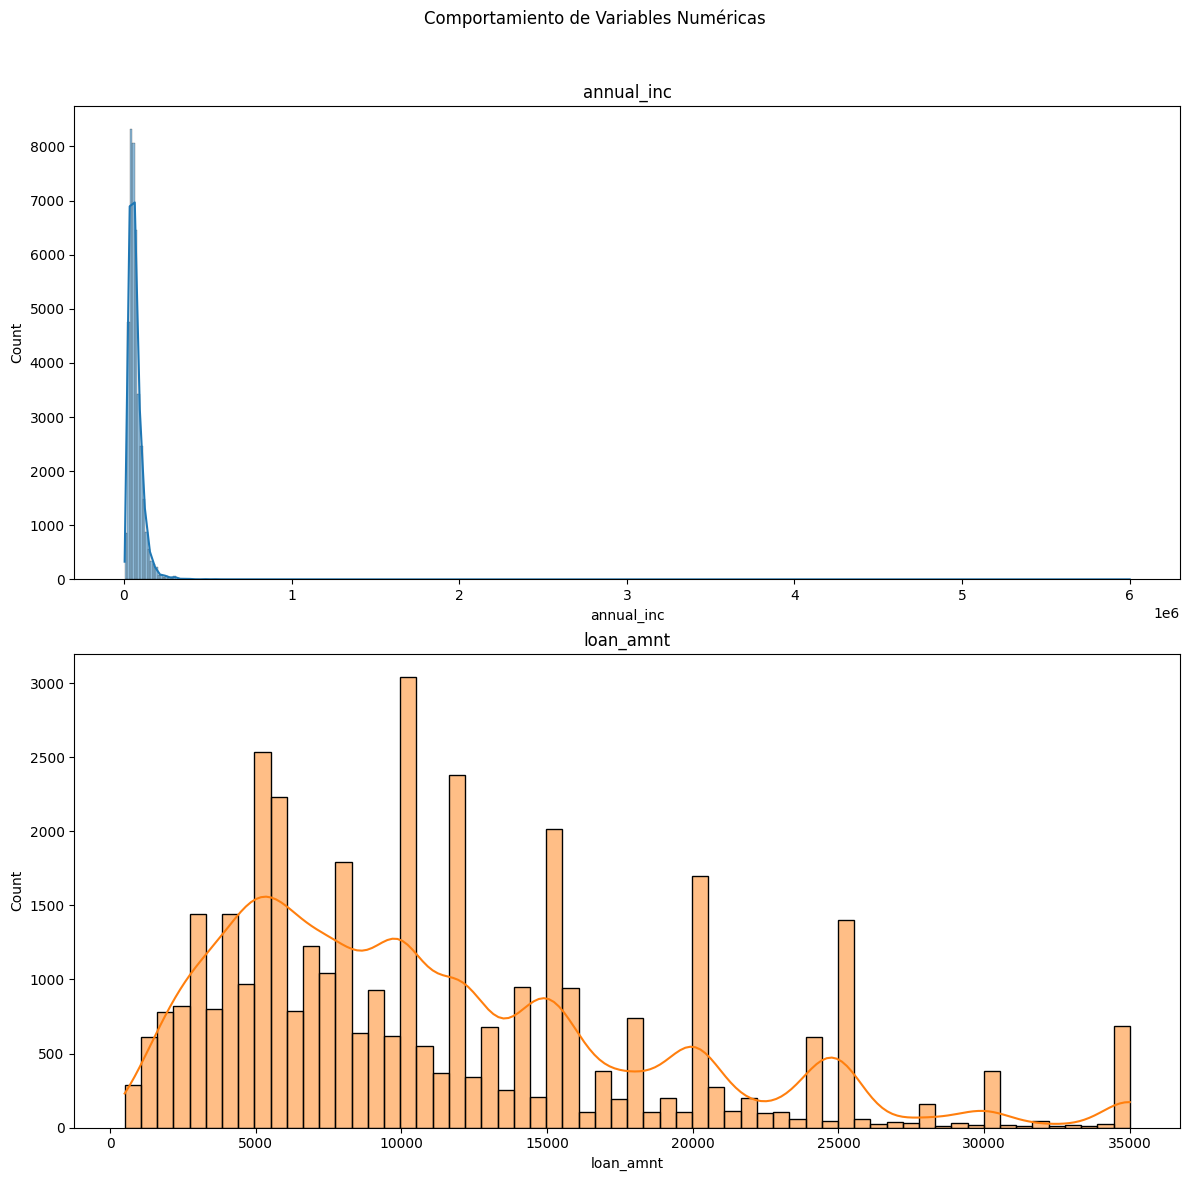

In [12]:
#Exploración univariada de los datos
##Para datos numéricos: histogramas de frecuencia
##Para datos categóricos: gráficos de torta

###HISTOGRAMAS DE FRECUENCIA
fig, ax = plt.subplots(2, 1, figsize = (12, 12))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns
for i, col in enumerate(num_col):
    sb.histplot(data = data, x = col, 
                kde = True, color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'], ax = ax[i])
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

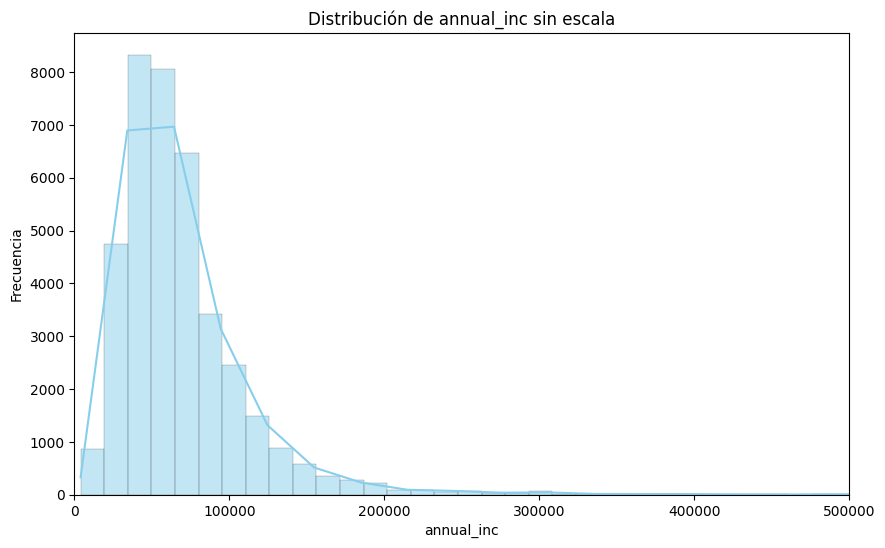

In [21]:
plt.figure(figsize=(10, 6))
sb.histplot(data=data, x='annual_inc', kde=True, color='skyblue')
plt.title('Distribución de annual_inc sin escala')
plt.xlabel('annual_inc')
plt.ylabel('Frecuencia')
plt.xlim(0, 500000)
plt.show()

In [16]:
data['annual_inc'].sort_values(ascending=False).head(n=20)

29172    6000000.0
28719    3900000.0
38080    2039784.0
22797    1900000.0
7011     1782000.0
32973    1440000.0
33295    1362000.0
10275    1250000.0
23392    1200000.0
20726    1200000.0
24935    1200000.0
32423    1200000.0
26704    1176000.0
28008    1080000.0
20694     948000.0
7289      900000.0
33175     900000.0
33288     900000.0
24990     900000.0
24358     889000.0
Name: annual_inc, dtype: float64

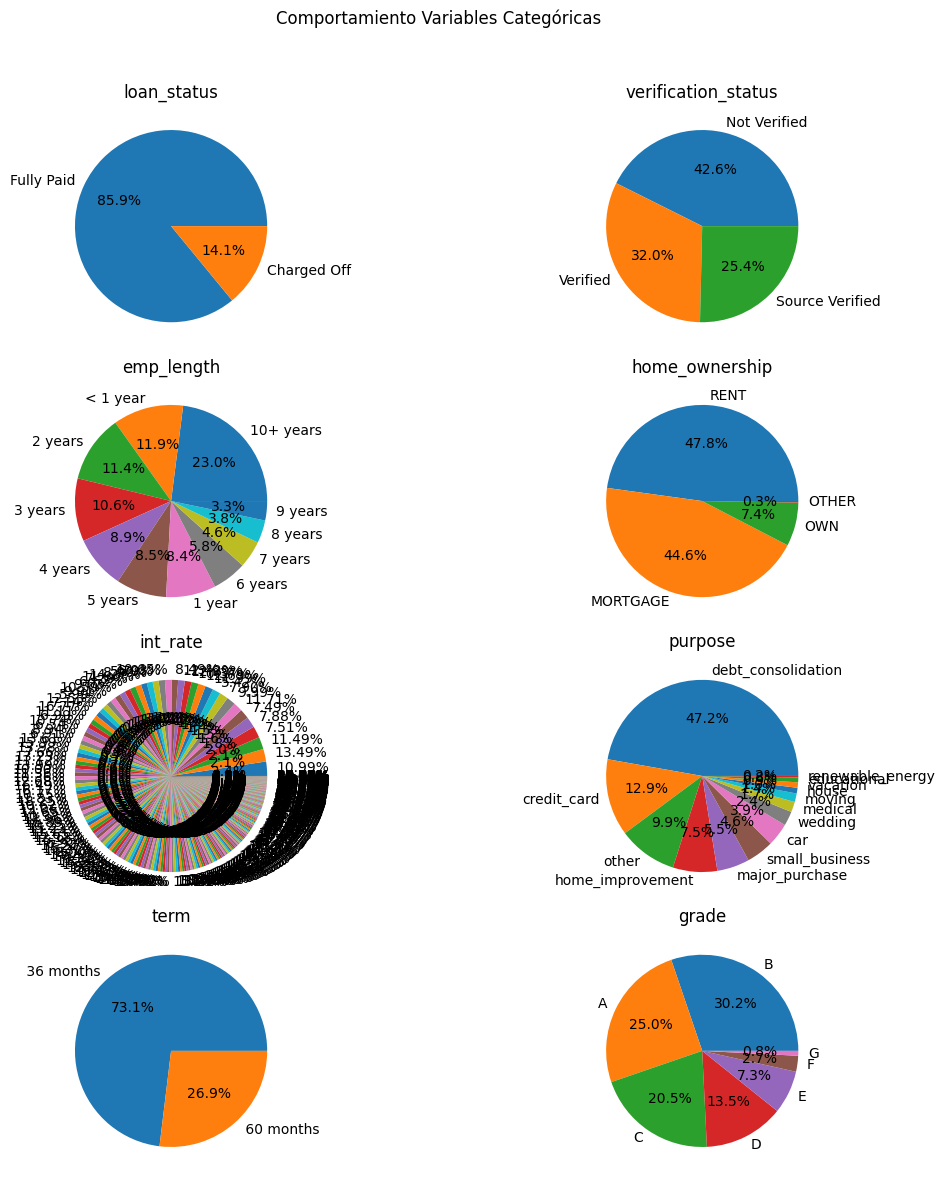

In [11]:
##GRÁFICOS DE TORTA
fig, ax = plt.subplots(4, 2, figsize = (12, 12))
ax = ax.flat
cat_col = data.select_dtypes(include = ['object']).columns
for i, col in enumerate(cat_col):
    ax[i].pie(x = data[col].value_counts(), labels = data[col].value_counts().index, autopct = '%0.1f%%')
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle("Comportamiento Variables Categóricas")
plt.show()

In [ ]:
data_a = data_mod[data_mod['grade'] == 'a']
data_b = data_mod[data_mod['grade'] == 'b']
data_c = data_mod[data_mod['grade'] == 'c']
data_d = data_mod[data_mod['grade'] == 'd']
data_e = data_mod[data_mod['grade'] == 'e']
data_f = data_mod[data_mod['grade'] == 'f']
data_g = data_mod[data_mod['grade'] == 'g']

print(f'El tamaño de la clase a es: {data_a.shape}')
print(f'El tamaño de la clase b es: {data_b.shape}')
print(f'El tamaño de la clase c es: {data_c.shape}')
print(f'El tamaño de la clase d es: {data_d.shape}')
print(f'El tamaño de la clase e es: {data_e.shape}')
print(f'El tamaño de la clase f es: {data_f.shape}')
print(f'El tamaño de la clase g es: {data_g.shape}')